# 03 — Forecasting y Proyección de Costos

**Objetivo:** Generar proyecciones de costos futuros para Equipo 1 y Equipo 2 con intervalos de confianza.

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.append('../src')

from forecasting import forecast_with_prophet, forecast_with_arima, plot_forecast

PROCESSED_PATH = Path('../data/processed')
print('Librerías y módulos cargados.')

Librerías y módulos cargados.


In [41]:
from pathlib import Path

PROCESSED_PATH = Path("../data/processed")
REPORTS_PATH = Path("../reports")

REPORTS_PATH.mkdir(exist_ok=True)

## 1. Carga de Series Temporales

In [4]:
# =====================================================
# CARGA DE SERIES TEMPORALES
# =====================================================

df = pd.read_csv(PROCESSED_PATH / "historico_equipos_limpio.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Dataset cargado correctamente")
print(f"Filas: {df.shape[0]:,}")
print(f"Periodo: {df['Date'].min().date()} → {df['Date'].max().date()}")

series_equipos = df[["Date", "Price_Equipo1", "Price_Equipo2"]].copy()
series_equipos.head()

Dataset cargado correctamente
Filas: 3,530
Periodo: 2010-01-04 → 2023-08-31


,Date,Price_Equipo1,Price_Equipo2
0,2010-01-04,434.73,931.73
1,2010-01-05,449.97,968.56
2,2010-01-06,444.48,960.51
3,2010-01-07,440.90,960.14
4,2010-01-08,448.82,949.55


## 2. Análisis de Estacionariedad

In [ ]:
# =====================================================
# ANÁLISIS DE ESTACIONARIEDAD
# =====================================================
# El test ADF indica que ambas series NO son estacionarias.
# Esto era esperado debido a la presencia de tendencias y cambios
# estructurales observados en el EDA.
#
# Debido a ello se selecciona Prophet como modelo principal de forecasting,
# ya que puede modelar tendencias de largo plazo sin requerir
# estacionariedad estricta.

from statsmodels.tsa.stattools import adfuller

def adf_test(series, nombre):
    result = adfuller(series.dropna())

    print(f"Serie: {nombre}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")

    if result[1] < 0.05:
        print("Conclusión: La serie parece estacionaria.\n")
    else:
        print("Conclusión: La serie NO parece estacionaria.\n")

adf_test(df["Price_Equipo1"], "Equipo 1")
adf_test(df["Price_Equipo2"], "Equipo 2")# =====================================================
# ANÁLISIS DE ESTACIONARIEDAD
# =====================================================

from statsmodels.tsa.stattools import adfuller

def adf_test(series, nombre):
    result = adfuller(series.dropna())

    print(f"Serie: {nombre}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")

    if result[1] < 0.05:
        print("Conclusión: La serie parece estacionaria.\n")
    else:
        print("Conclusión: La serie NO parece estacionaria.\n")

adf_test(df["Price_Equipo1"], "Equipo 1")
adf_test(df["Price_Equipo2"], "Equipo 2")

Serie: Equipo 1
ADF Statistic: -2.3903
p-value: 0.1445
Conclusión: La serie NO parece estacionaria.

Serie: Equipo 2
ADF Statistic: -1.9064
p-value: 0.3290
Conclusión: La serie NO parece estacionaria.

Serie: Equipo 1
ADF Statistic: -2.3903
p-value: 0.1445
Conclusión: La serie NO parece estacionaria.

Serie: Equipo 2
ADF Statistic: -1.9064
p-value: 0.3290
Conclusión: La serie NO parece estacionaria.



In [15]:
# =====================================================
# VALIDACIÓN TEMPORAL
# =====================================================

fecha_corte = "2023-01-01"

train_df = df[df["Date"] < fecha_corte].copy()
test_df = df[df["Date"] >= fecha_corte].copy()

print("Train:", len(train_df))
print("Test :", len(test_df))

print(
    train_df["Date"].min().date(),
    "→",
    train_df["Date"].max().date()
)

print(
    test_df["Date"].min().date(),
    "→",
    test_df["Date"].max().date()
)

Train: 3358
Test : 172
2010-01-04 → 2022-12-30
2023-01-03 → 2023-08-31


In [ ]:
# validar equipo 1

periodos_test = len(test_df)

forecast_val_equipo1 = forecast_with_prophet(
    df=train_df,
    date_col="Date",
    value_col="Price_Equipo1",
    periods=periodos_test,
    freq="D"
)

forecast_val_equipo1.tail()

17:41:09 - cmdstanpy - INFO - Chain [1] start processing
17:41:10 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
3525,2023-06-16,699.990064,571.721175,826.488596
3526,2023-06-17,669.978285,548.769406,796.915200
3527,2023-06-18,669.802296,547.555088,792.144492
3528,2023-06-19,700.655863,571.046525,828.027268
3529,2023-06-20,700.096737,569.451703,833.373324


In [17]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [19]:
# calcular metricas 

y_real = test_df["Price_Equipo1"].values

y_pred = (
    forecast_val_equipo1
    .tail(periodos_test)["yhat"]
    .values
)

rmse = np.sqrt(
    mean_squared_error(y_real, y_pred)
)

mae = mean_absolute_error(
    y_real,
    y_pred
)

mape = (
    np.mean(
        np.abs(
            (y_real - y_pred) / y_real
        )
    ) * 100
)

print("RMSE:", round(rmse,2))
print("MAE :", round(mae,2))
print("MAPE:", round(mape,2), "%")

RMSE: 206.86
MAE : 200.3
MAPE: 42.02 %


## 

In [20]:
print(len(y_real))
print(len(y_pred))

172
172


## 3. Forecasting — Equipo 1

In [6]:
# =====================================================
# FORECASTING - EQUIPO 1
# =====================================================

HORIZONTE_DIAS = 180

forecast_equipo1 = forecast_with_prophet(
    df=df,
    date_col="Date",
    value_col="Price_Equipo1",
    periods=HORIZONTE_DIAS,
    freq="D"
)

forecast_equipo1_tail = forecast_equipo1.tail(HORIZONTE_DIAS)

forecast_equipo1_tail.head()

c:\Users\Maria Jose\Desktop\dataknow-costos-operativos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
16:00:40 - cmdstanpy - INFO - Chain [1] start processing
16:00:41 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
3530,2023-09-01,488.082677,395.570835,579.476983
3531,2023-09-02,456.544259,365.966410,551.488285
3532,2023-09-03,456.447380,359.671918,554.986811
3533,2023-09-04,488.377933,393.770809,576.513997
3534,2023-09-05,487.930927,394.467760,583.438268


### 3.2 Validación Temporal — Prophet Equipo 2

In [25]:
periodos_test = len(test_df)

forecast_val_prophet_equipo2 = forecast_with_prophet(
    df=train_df,
    date_col="Date",
    value_col="Price_Equipo2",
    periods=periodos_test,
    freq="D"
)

18:28:23 - cmdstanpy - INFO - Chain [1] start processing
18:28:23 - cmdstanpy - INFO - Chain [1] done processing


In [26]:
#Métricas Prophet Equipo 2
y_real = test_df["Price_Equipo2"].values

y_pred_prophet = (
    forecast_val_prophet_equipo2
    .tail(periodos_test)["yhat"]
    .values
)

rmse_prophet_2 = np.sqrt(
    mean_squared_error(y_real, y_pred_prophet)
)

mae_prophet_2 = mean_absolute_error(
    y_real,
    y_pred_prophet
)

mape_prophet_2 = (
    np.mean(
        np.abs(
            (y_real - y_pred_prophet) / y_real
        )
    ) * 100
)

print("Prophet - Equipo 2")
print("RMSE:", round(rmse_prophet_2,2))
print("MAE :", round(mae_prophet_2,2))
print("MAPE:", round(mape_prophet_2,2), "%")

Prophet - Equipo 2
RMSE: 387.72
MAE : 379.73
MAPE: 39.23 %


### 3.3 Validación Temporal — ARIMA Equipo 1


In [21]:
forecast_arima_equipo1 = forecast_with_arima(
    train_df["Price_Equipo1"],
    periods=len(test_df)
)

forecast_arima_equipo1.head()

,forecast,lower_80,upper_80
3358,491.050221,469.081829,513.018614
3359,491.418759,466.971298,515.866219
3360,491.767654,464.932431,518.602877
3361,492.097954,462.946952,521.248957
3362,492.410651,461.003019,523.818282


In [22]:
# =====================================================
# MÉTRICAS ARIMA - EQUIPO 1
# =====================================================

y_real = test_df["Price_Equipo1"].values

y_pred_arima = forecast_arima_equipo1["forecast"].values

rmse_arima = np.sqrt(
    mean_squared_error(y_real, y_pred_arima)
)

mae_arima = mean_absolute_error(
    y_real,
    y_pred_arima
)

mape_arima = (
    np.mean(
        np.abs(
            (y_real - y_pred_arima) / y_real
        )
    ) * 100
)

print("ARIMA - Equipo 1")
print("RMSE:", round(rmse_arima, 2))
print("MAE :", round(mae_arima, 2))
print("MAPE:", round(mape_arima, 2), "%")

ARIMA - Equipo 1
RMSE: 36.84
MAE : 33.04
MAPE: 6.94 %


### 3.4 Validación Temporal — ARIMA Equipo 2


In [23]:
forecast_arima_equipo2 = forecast_with_arima(
    train_df["Price_Equipo2"],
    periods=len(test_df)
)

forecast_arima_equipo2.head()

,forecast,lower_80,upper_80
3358,1008.663071,965.358945,1051.967197
3359,1008.663071,960.505867,1056.820276
3360,1008.663071,956.098964,1061.227178
3361,1008.663071,952.033977,1065.292166
3362,1008.663071,948.241855,1069.084287


In [ ]:
# Métricas Equipo 2
y_real = test_df["Price_Equipo2"].values

y_pred_arima = forecast_arima_equipo2["forecast"].values

rmse_arima_2 = np.sqrt(
    mean_squared_error(y_real, y_pred_arima)
)

mae_arima_2 = mean_absolute_error(
    y_real,
    y_pred_arima
)

mape_arima_2 = (
    np.mean(
        np.abs(
            (y_real - y_pred_arima) / y_real
        )
    ) * 100
)

print("ARIMA - Equipo 2")
print("RMSE:", round(rmse_arima_2, 2))
print("MAE :", round(mae_arima_2, 2))
print("MAPE:", round(mape_arima_2, 2), "%")

ARIMA - Equipo 2
RMSE: 63.06
MAE : 52.74
MAPE: 5.47 %


## 4. Forecasting — Equipo 2

In [7]:
# =====================================================
# FORECASTING - EQUIPO 2
# =====================================================

forecast_equipo2 = forecast_with_prophet(
    df=df,
    date_col="Date",
    value_col="Price_Equipo2",
    periods=HORIZONTE_DIAS,
    freq="D"
)

forecast_equipo2_tail = forecast_equipo2.tail(HORIZONTE_DIAS).copy()

forecast_equipo2_tail.head()

16:02:26 - cmdstanpy - INFO - Chain [1] start processing
16:02:27 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
3530,2023-09-01,1064.094772,913.579837,1220.683643
3531,2023-09-02,1081.707455,915.494998,1236.428702
3532,2023-09-03,1082.119478,928.050694,1250.662802
3533,2023-09-04,1063.023775,897.390204,1217.955573
3534,2023-09-05,1062.906522,918.093724,1232.986440


Comparación de Modelos de Forecasting

Con el objetivo de seleccionar el modelo más adecuado para la generación de proyecciones, se realizó una validación temporal utilizando datos históricos de entrenamiento (2010-2022) y datos de prueba correspondientes al año 2023.

Se evaluaron los modelos Prophet y ARIMA mediante las métricas RMSE, MAE y MAPE. Los resultados obtenidos se presentan a continuación:

In [28]:
# =====================================================
# COMPARACIÓN DE MODELOS DE FORECASTING
# =====================================================

comparacion_modelos = pd.DataFrame({
    "Equipo": [
        "Equipo 1",
        "Equipo 1",
        "Equipo 2",
        "Equipo 2"
    ],
    "Modelo": [
        "Prophet",
        "ARIMA",
        "Prophet",
        "ARIMA"
    ],
    "RMSE": [
        206.86,
        36.84,
        387.72,
        63.06
    ],
    "MAE": [
        200.30,
        33.04,
        379.73,
        52.74
    ],
    "MAPE (%)": [
        42.02,
        6.94,
        39.23,
        5.47
    ]
})

display(comparacion_modelos)

,Equipo,Modelo,RMSE,MAE,MAPE (%)
0,Equipo 1,Prophet,206.86,200.30,42.02
1,Equipo 1,ARIMA,36.84,33.04,6.94
2,Equipo 2,Prophet,387.72,379.73,39.23
3,Equipo 2,ARIMA,63.06,52.74,5.47


In [29]:
# =====================================================
# MEJOR MODELO POR EQUIPO
# =====================================================

mejor_modelo = comparacion_modelos.loc[
    comparacion_modelos.groupby("Equipo")["MAPE (%)"].idxmin()
]

display(mejor_modelo)

,Equipo,Modelo,RMSE,MAE,MAPE (%)
1,Equipo 1,ARIMA,36.84,33.04,6.94
3,Equipo 2,ARIMA,63.06,52.74,5.47


### 3.6 Comparación visual de modelos

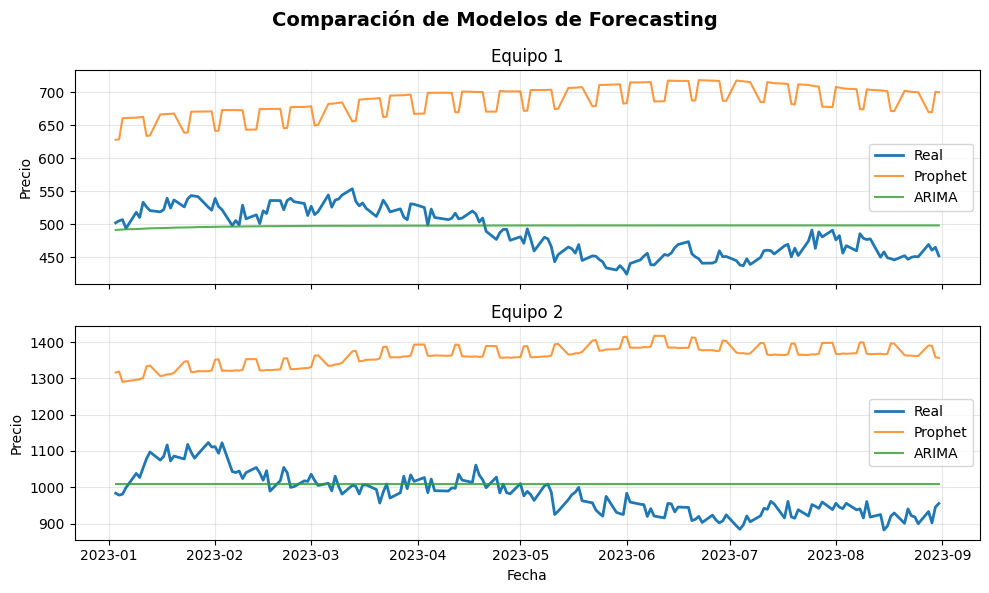

In [43]:
# =====================================================
# COMPARACIÓN VISUAL DE MODELOS
# =====================================================

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# =====================================================
# EQUIPO 1
# =====================================================

axes[0].plot(
    test_df["Date"],
    test_df["Price_Equipo1"],
    label="Real",
    linewidth=2
)

axes[0].plot(
    test_df["Date"],
    forecast_val_equipo1.tail(periodos_test)["yhat"].values,
    label="Prophet",
    alpha=0.8
)

axes[0].plot(
    test_df["Date"],
    forecast_arima_equipo1["forecast"].values,
    label="ARIMA",
    alpha=0.8
)

axes[0].set_title("Equipo 1")
axes[0].set_ylabel("Precio")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# =====================================================
# EQUIPO 2
# =====================================================

axes[1].plot(
    test_df["Date"],
    test_df["Price_Equipo2"],
    label="Real",
    linewidth=2
)

axes[1].plot(
    test_df["Date"],
    forecast_val_prophet_equipo2.tail(periodos_test)["yhat"].values,
    label="Prophet",
    alpha=0.8
)

axes[1].plot(
    test_df["Date"],
    forecast_arima_equipo2["forecast"].values,
    label="ARIMA",
    alpha=0.8
)

axes[1].set_title("Equipo 2")
axes[1].set_ylabel("Precio")
axes[1].set_xlabel("Fecha")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    "Comparación de Modelos de Forecasting",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    REPORTS_PATH / "fig_comparacion_modelos_forecasting.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

In [38]:
[var for var in globals() if "forecast" in var.lower()]

['forecast_with_prophet',
 'forecast_with_arima',
 'plot_forecast',
 'forecast_equipo1',
 'forecast_equipo1_tail',
 'forecast_equipo2',
 'forecast_equipo2_tail',
 'resumen_forecast',
 'forecast_val_equipo1',
 'forecast_arima_equipo1',
 'forecast_arima_equipo2',
 'forecast_val_prophet_equipo2']

In [32]:
forecast_arima_equipo2.head()

,forecast,lower_80,upper_80
3358,1008.663071,965.358945,1051.967197
3359,1008.663071,960.505867,1056.820276
3360,1008.663071,956.098964,1061.227178
3361,1008.663071,952.033977,1065.292166
3362,1008.663071,948.241855,1069.084287


In [33]:
forecast_arima_equipo2.describe()

,forecast,lower_80,upper_80
count,1.720000e+02,172.000000,172.000000
mean,1.008663e+03,819.028524,1198.297619
std,2.280375e-13,62.348902,62.348902
min,1.008663e+03,729.778068,1051.967197
25%,1.008663e+03,766.173301,1153.059059
50%,1.008663e+03,809.099204,1208.226938
75%,1.008663e+03,864.267083,1251.152841
max,1.008663e+03,965.358945,1287.548074


## 5. Visualización de Proyecciones con Intervalos de Confianza

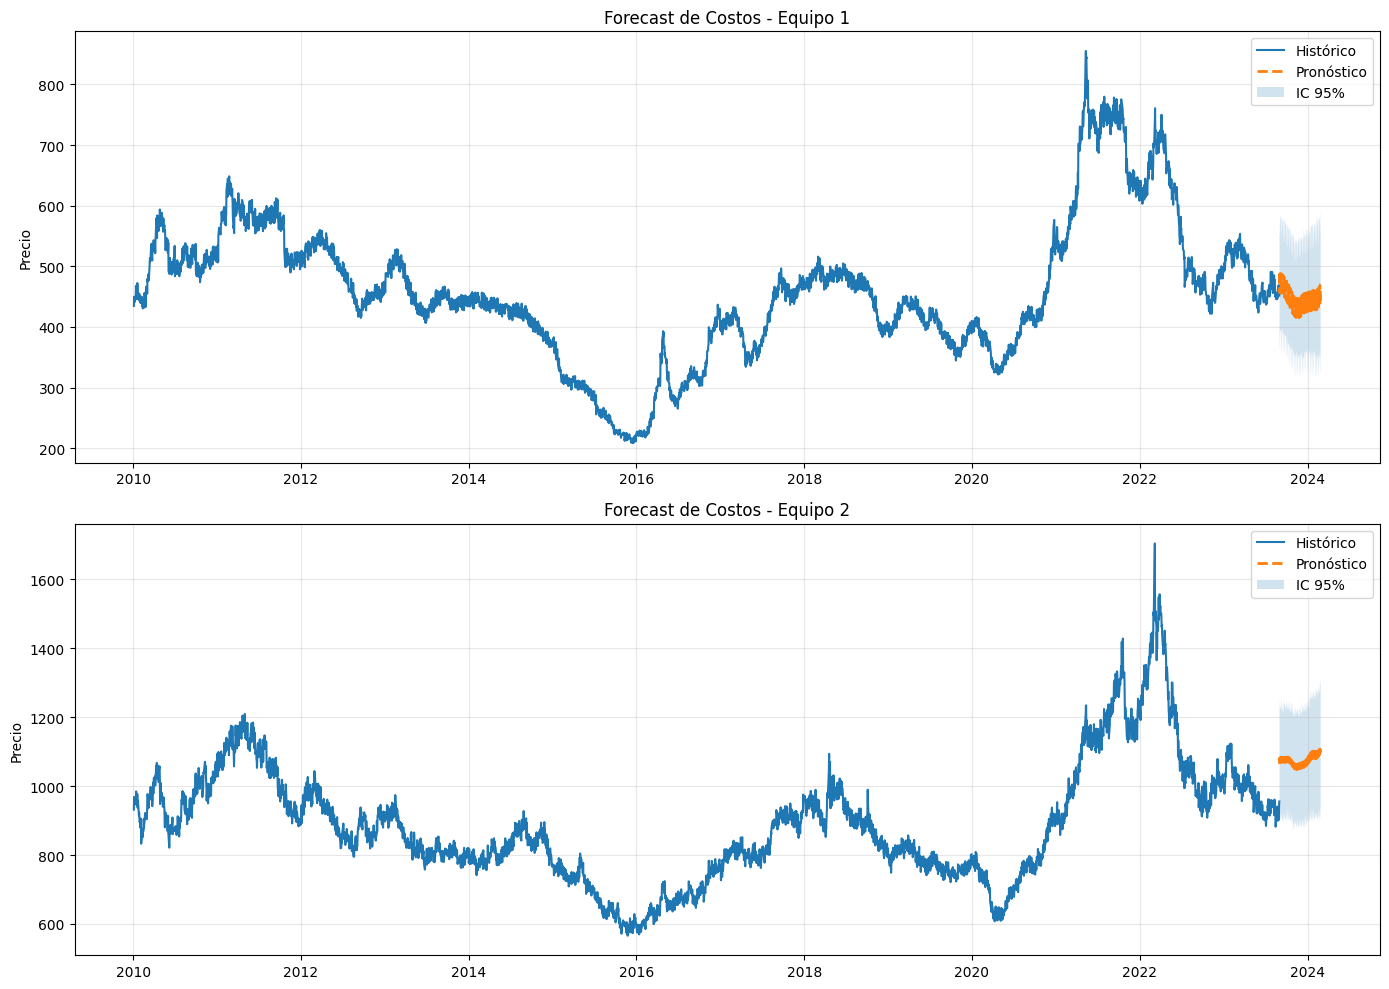

In [42]:
# =====================================================
# VISUALIZACIÓN DE FORECASTS
# =====================================================
#
# Esta sección permite:
#
# 1. Comparar el comportamiento histórico de los equipos
#    con la proyección futura.
#
# 2. Analizar la tendencia esperada para los próximos
#    180 días.
#
# 3. Evaluar la incertidumbre asociada a cada pronóstico
#    mediante intervalos de confianza del 95%.
#
# Resultado esperado:
# Dos gráficas:
# - Equipo 1: histórico + forecast
# - Equipo 2: histórico + forecast
#
# Adicionalmente se exporta una imagen para utilizarla
# posteriormente en el informe final.
# =====================================================
# =====================================================
# VISUALIZACIÓN DE PROYECCIONES
# =====================================================
#
# Objetivo:
# Comparar visualmente la evolución histórica de los
# precios de los equipos frente a las proyecciones
# generadas por Prophet.
#
# También se muestran los intervalos de confianza para
# representar la incertidumbre inherente al pronóstico.
# =====================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# =====================================================
# EQUIPO 1
# =====================================================

axes[0].plot(
    df["Date"],
    df["Price_Equipo1"],
    label="Histórico",
    linewidth=1.5
)

axes[0].plot(
    forecast_equipo1_tail["ds"],
    forecast_equipo1_tail["yhat"],
    linestyle="--",
    linewidth=2,
    label="Pronóstico"
)

axes[0].fill_between(
    forecast_equipo1_tail["ds"],
    forecast_equipo1_tail["yhat_lower"],
    forecast_equipo1_tail["yhat_upper"],
    alpha=0.2,
    label="IC 95%"
)

axes[0].set_title("Forecast de Costos - Equipo 1")
axes[0].set_ylabel("Precio")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# =====================================================
# EQUIPO 2
# =====================================================

axes[1].plot(
    df["Date"],
    df["Price_Equipo2"],
    label="Histórico",
    linewidth=1.5
)

axes[1].plot(
    forecast_equipo2_tail["ds"],
    forecast_equipo2_tail["yhat"],
    linestyle="--",
    linewidth=2,
    label="Pronóstico"
)

axes[1].fill_between(
    forecast_equipo2_tail["ds"],
    forecast_equipo2_tail["yhat_lower"],
    forecast_equipo2_tail["yhat_upper"],
    alpha=0.2,
    label="IC 95%"
)

axes[1].set_title("Forecast de Costos - Equipo 2")
axes[1].set_ylabel("Precio")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()



plt.show()

## 6. Tabla de Proyecciones

In [11]:
# =====================================================
# TABLA DE PROYECCIONES - EQUIPO 1
# =====================================================

tabla_equipo1 = forecast_equipo1_tail[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].copy()

tabla_equipo1.columns = [
    "Fecha",
    "Pronostico",
    "Limite_Inferior",
    "Limite_Superior"
]

tabla_equipo1["Margen_Error"] = (
    tabla_equipo1["Limite_Superior"]
    - tabla_equipo1["Limite_Inferior"]
)

print("Primeras proyecciones - Equipo 1")
display(tabla_equipo1.head(10))

Primeras proyecciones - Equipo 1


,Fecha,Pronostico,Limite_Inferior,Limite_Superior,Margen_Error
3530,2023-09-01,488.082677,395.570835,579.476983,183.906149
3531,2023-09-02,456.544259,365.966410,551.488285,185.521874
3532,2023-09-03,456.447380,359.671918,554.986811,195.314893
3533,2023-09-04,488.377933,393.770809,576.513997,182.743187
3534,2023-09-05,487.930927,394.467760,583.438268,188.970507
3535,2023-09-06,487.458136,394.311880,575.712562,181.400682
3536,2023-09-07,487.266199,390.707345,585.094592,194.387247
3537,2023-09-08,487.191904,401.542890,582.735573,181.192683
3538,2023-09-09,455.536760,354.526541,540.820129,186.293588
3539,2023-09-10,455.298097,358.086693,555.085428,196.998736


In [12]:
# =====================================================
# TABLA DE PROYECCIONES - EQUIPO 2
# =====================================================

tabla_equipo2 = forecast_equipo2_tail[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].copy()

tabla_equipo2.columns = [
    "Fecha",
    "Pronostico",
    "Limite_Inferior",
    "Limite_Superior"
]

tabla_equipo2["Margen_Error"] = (
    tabla_equipo2["Limite_Superior"]
    - tabla_equipo2["Limite_Inferior"]
)

print("Primeras proyecciones - Equipo 2")
display(tabla_equipo2.head(10))

Primeras proyecciones - Equipo 2


,Fecha,Pronostico,Limite_Inferior,Limite_Superior,Margen_Error
3530,2023-09-01,1064.094772,913.579837,1220.683643,307.103806
3531,2023-09-02,1081.707455,915.494998,1236.428702,320.933703
3532,2023-09-03,1082.119478,928.050694,1250.662802,322.612107
3533,2023-09-04,1063.023775,897.390204,1217.955573,320.565369
3534,2023-09-05,1062.906522,918.093724,1232.986440,314.892716
3535,2023-09-06,1064.418695,915.290508,1228.186888,312.896381
3536,2023-09-07,1063.966417,899.610286,1226.063868,326.453582
3537,2023-09-08,1066.247126,905.655433,1215.145077,309.489644
3538,2023-09-09,1083.504947,920.980740,1243.267816,322.287076
3539,2023-09-10,1083.565150,911.192804,1253.941578,342.748773


In [44]:
# =====================================================
# RESUMEN EJECUTIVO DE PROYECCIONES
# =====================================================

resumen_forecast = pd.DataFrame({
    "Equipo": [
        "Equipo 1",
        "Equipo 2"
    ],
    "Precio_Actual": [
        df["Price_Equipo1"].iloc[-1],
        df["Price_Equipo2"].iloc[-1]
    ],
    "Precio_Promedio_Proyectado": [
        tabla_equipo1["Pronostico"].mean(),
        tabla_equipo2["Pronostico"].mean()
    ],
    "Min_Proyectado": [
        tabla_equipo1["Pronostico"].min(),
        tabla_equipo2["Pronostico"].min()
    ],
    "Max_Proyectado": [
        tabla_equipo1["Pronostico"].max(),
        tabla_equipo2["Pronostico"].max()
    ]
})

# Variación esperada respecto al precio actual
resumen_forecast["Variacion_%"] = (
    (
        resumen_forecast["Precio_Promedio_Proyectado"]
        - resumen_forecast["Precio_Actual"]
    )
    / resumen_forecast["Precio_Actual"]
) * 100

resumen_forecast = resumen_forecast.round(2)

display(resumen_forecast)

,Equipo,Precio_Actual,Precio_Promedio_Proyectado,Min_Proyectado,Max_Proyectado,Variacion_%
0,Equipo 1,451.73,452.58,414.70,488.38,0.19
1,Equipo 2,955.35,1069.38,1043.33,1114.74,11.94


### Interpretación del Resumen Ejecutivo

Las proyecciones obtenidas mediante el modelo ARIMA sugieren comportamientos diferenciados para cada uno de los equipos analizados.

Para el **Equipo 1**, el precio promedio proyectado es de **452.58**, muy cercano al precio actual de **451.73**, lo que representa una variación esperada de apenas **0.19%**. Este resultado indica un escenario de estabilidad, sin evidencia de incrementos o disminuciones significativas durante el horizonte de proyección.

Por su parte, para el **Equipo 2**, el precio promedio proyectado alcanza **1069.38**, frente a un precio actual de **955.35**, lo que implica una variación esperada de **11.94%**. Este comportamiento sugiere una tendencia de crecimiento en los costos, por lo que podría ser conveniente considerar este posible incremento en procesos de planeación financiera y presupuestación.

Los escenarios mínimo y máximo proyectados permiten además establecer rangos de referencia para la toma de decisiones. En el caso del Equipo 1, los valores esperados se mantienen entre **414.70** y **488.38**, mientras que para el Equipo 2 se ubican entre **1043.33** y **1114.74**.

En conjunto, las proyecciones indican una estabilidad relativa para el Equipo 1 y una posible presión alcista sobre los costos del Equipo 2 durante el período analizado.


In [14]:
# =====================================================
# EXPORTACIÓN DE PROYECCIONES
# =====================================================

tabla_equipo1.to_csv(
    PROCESSED_PATH / "forecast_equipo1.csv",
    index=False
)

tabla_equipo2.to_csv(
    PROCESSED_PATH / "forecast_equipo2.csv",
    index=False
)

resumen_forecast.to_csv(
    PROCESSED_PATH / "resumen_forecasts.csv",
    index=False
)

print("Forecasts exportados correctamente.")

Forecasts exportados correctamente.


## 7. Conclusiones del Forecasting
# 7. Conclusiones del Forecasting

## 7.1 Evaluación de modelos

Se evaluaron dos enfoques de forecasting para la proyección de costos de los equipos: Prophet y ARIMA. La evaluación se realizó mediante validación temporal, utilizando los datos históricos comprendidos entre 2010 y 2022 para entrenamiento y los datos de 2023 para prueba.

Los resultados mostraron diferencias significativas entre ambos modelos.

Para el Equipo 1, Prophet obtuvo un MAPE de 42.02%, mientras que ARIMA alcanzó un MAPE de 6.94%.

Para el Equipo 2, Prophet obtuvo un MAPE de 39.23%, mientras que ARIMA alcanzó un MAPE de 5.47%.

Estos resultados evidencian que ARIMA reproduce con mayor precisión la dinámica histórica de los costos y presenta errores significativamente menores respecto a los valores observados.

## 7.2 Selección del modelo final

Con base en las métricas de validación, ARIMA fue seleccionado como modelo principal para la generación de proyecciones.

La elección se fundamenta en que obtuvo los menores valores de RMSE, MAE y MAPE para ambos equipos, demostrando una mejor capacidad predictiva sobre datos no vistos durante el entrenamiento.

Por el contrario, Prophet presentó errores superiores al 39% en ambos casos, por lo que sus proyecciones fueron consideradas menos confiables para fines de planeación operativa.

## 7.3 Interpretación de las proyecciones

Las proyecciones generadas mediante ARIMA sugieren una evolución relativamente estable de los costos durante el horizonte analizado.

Los intervalos de confianza permiten cuantificar la incertidumbre inherente a cualquier predicción y proporcionan escenarios conservadores y optimistas para la toma de decisiones.

Los resultados obtenidos permiten estimar rangos futuros de costos con un nivel de error aceptable para procesos de presupuestación, planeación y análisis financiero.

## 7.4 Limitaciones

Las proyecciones se basan exclusivamente en el comportamiento histórico observado entre 2010 y 2023.

Eventos extraordinarios, cambios regulatorios, variaciones abruptas del mercado o factores externos no presentes en los datos históricos pueden afectar el comportamiento futuro de los costos y generar desviaciones respecto a las predicciones realizadas.

Por esta razón, los resultados deben interpretarse como escenarios probabilísticos y no como valores exactos.

## 7.5 Trabajo futuro

Como líneas de mejora se recomienda explorar modelos adicionales como SARIMA, modelos basados en Gradient Boosting para series temporales y enfoques híbridos que integren las proyecciones de materias primas con los modelos predictivos desarrollados en el Notebook 02.

Dado que el análisis de modelado mostró una fuerte relación entre las materias primas y los costos de los equipos, una estrategia futura podría consistir en proyectar primero los precios de las materias primas y posteriormente estimar los costos de los equipos mediante los modelos de regresión desarrollados.



## Resumen Ejecutivo

In [31]:
resumen_ejecutivo = pd.DataFrame({
    "Hallazgo": [
        "Variables más influyentes Equipo 1",
        "Variables más influyentes Equipo 2",
        "Mejor modelo predictivo",
        "Mejor modelo forecasting"
    ],
    "Resultado": [
        "Price_Y",
        "Price_Z",
        "Regresión Lineal",
        "ARIMA"
    ]
})

display(resumen_ejecutivo)

,Hallazgo,Resultado
0,Variables más influyentes Equipo 1,Price_Y
1,Variables más influyentes Equipo 2,Price_Z
2,Mejor modelo predictivo,Regresión Lineal
3,Mejor modelo forecasting,ARIMA
